In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_noise/int_3mth_pm_seed_tm_1'


In [ ]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [ ]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.864585  ,  0.333715  ,  0.045837  ,  0.725319  ,  0.490583  ],
        [ 0.86458344,  0.33370199,  0.04582634,  0.72531667,  0.49059159],
        [ 0.86460903,  0.33372359,  0.04584481,  0.72530817,  0.49057139],
        ...,
        [ 0.48617375,  0.45319489,  0.44763464,  0.0253545 ,  0.43489479],
        [ 0.32117463, -0.47267786,  0.99418276,  0.219296  ,  0.62624914],
        [ 0.38851508,  0.58738627,  0.06253276,  1.28263287,  0.04261675]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([4.69882643, 4.69738504, 4.75173833, ..., 1.22631659,       -inf,
              -inf])]

In [7]:
sampler.now_covariances

[array([[ 0.02452682,  0.04115265, -0.00656758, -0.01070796, -0.01004634],
        [ 0.04115265,  0.25037355, -0.04138399,  0.03784603,  0.00973607],
        [-0.00656758, -0.04138399,  0.07459151,  0.00706681,  0.03807109],
        [-0.01070796,  0.03784603,  0.00706681,  0.094856  ,  0.02479761],
        [-0.01004634,  0.00973607,  0.03807109,  0.02479761,  0.22658994]])]

In [8]:
np.argmax(logden_list)

2310

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 6.29332246,  0.97236086,  0.3347499 , 10.18644061,  0.34722833]])

In [10]:
log_density(maxld_pt1)

array([6.22615631])

In [11]:
log_density([param_true])

array([8.61286619])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

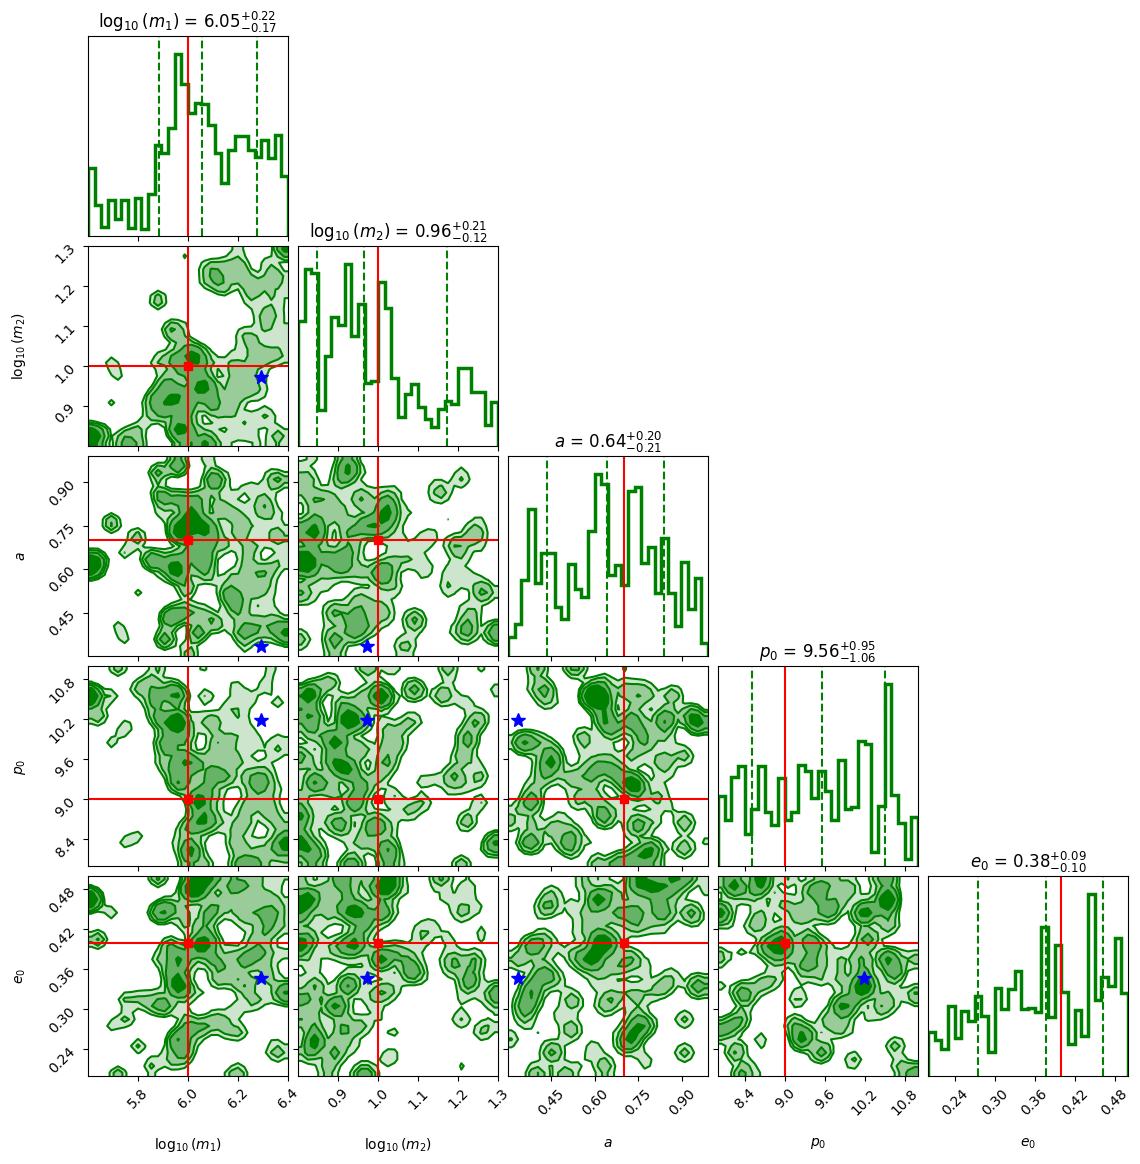

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[      -inf,       -inf,       -inf, ..., 5.98218124, 6.02755289,
        6.22615631]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([2310, 2025, 2328, 2402, 2003, 2407, 2028, 1920, 1935, 2084])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[ 6.29332246,  0.97236086,  0.3347499 , 10.18644061,  0.34722833],
       [ 6.29337804,  0.97284629,  0.3327823 , 10.19140855,  0.34730738],
       [ 6.29374385,  0.97495678,  0.33334861, 10.19179655,  0.34586483],
       [ 6.29294381,  0.97294173,  0.3329721 , 10.19219889,  0.34789331],
       [ 6.29269704,  0.97353876,  0.33233711, 10.19417809,  0.3483083 ],
       [ 6.29176698,  0.97125761,  0.32933906, 10.20219118,  0.34763554],
       [ 6.29226025,  0.97197272,  0.33167756, 10.19663228,  0.34906389],
       [ 6.29265774,  0.96957901,  0.33254255, 10.1797364 ,  0.34714802],
       [ 6.29251441,  0.96931903,  0.33241395, 10.18000465,  0.34735124],
       [ 6.29281782,  0.97453496,  0.33409997, 10.18728096,  0.34816961]])

In [18]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [19]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [20]:
import matplotlib.pyplot as plt

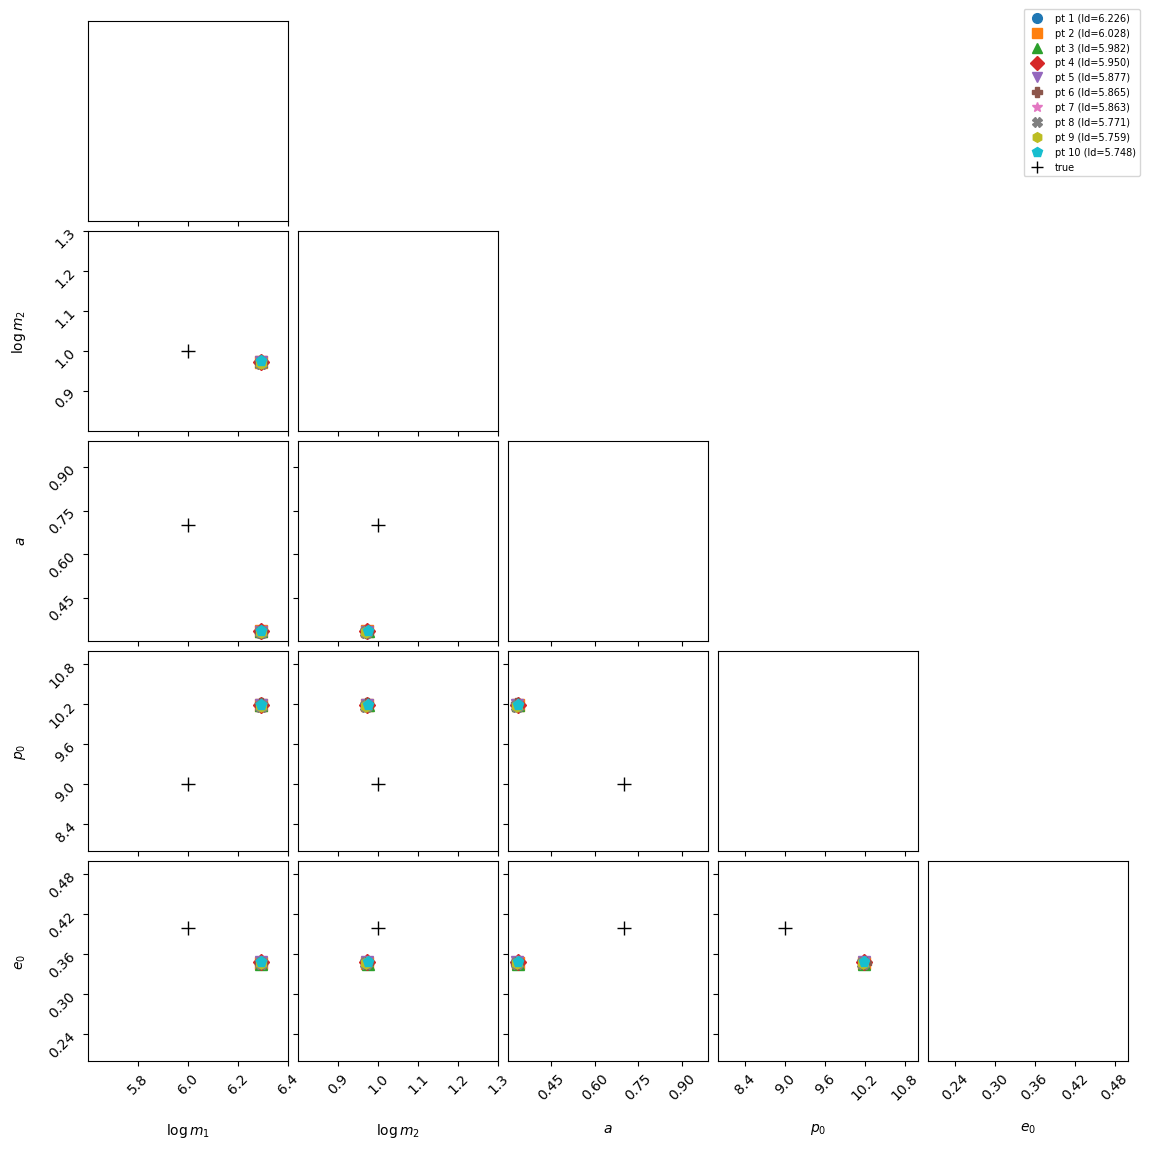

In [21]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

# connection plot

In [22]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[ 6.29332246,  0.97236086,  0.3347499 , 10.18644061,  0.34722833]])

In [23]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [24]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [25]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [26]:
logden_theory_proc1

array([6.22615631, 3.55259611, 3.1040596 , 2.41398908, 1.65505484,
       2.44106227, 2.55928557, 1.75511988, 1.70197563, 2.31955679,
       1.60609517, 2.2437032 , 2.36071477, 1.64413792, 1.959872  ,
       3.19108907, 2.90533324, 1.97256678, 2.43416802, 3.53578618,
       1.97387342, 3.87155757, 2.82124744, 2.52062035, 4.1791784 ,
       1.98599943, 3.68171627, 3.55959488, 3.79326658, 4.20412678,
       3.0978834 , 2.95187947, 3.46666849, 4.55543127, 3.43722559,
       4.5841234 , 3.26657771, 3.07188577, 4.27423835, 4.487901  ,
       2.82440023, 3.79728841, 3.0747446 , 3.1770044 , 3.11769423,
       3.56852423, 2.69627663, 3.83907708, 3.09075963, 8.61286619])

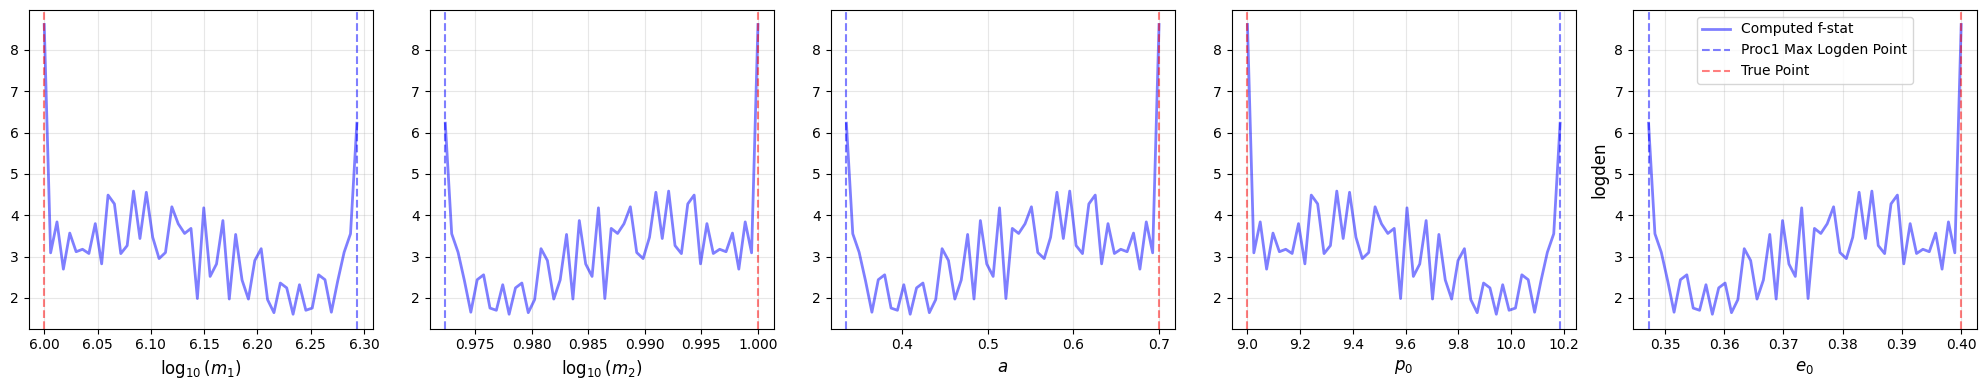

In [27]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


Initializing timemax...
Initializing phasemax...
Initializing tmXonly...
Initializing pure...
All initialized.
Evaluating timemax...
Evaluating phasemax...
Evaluating tmXonly...
Evaluating pure...
Done.


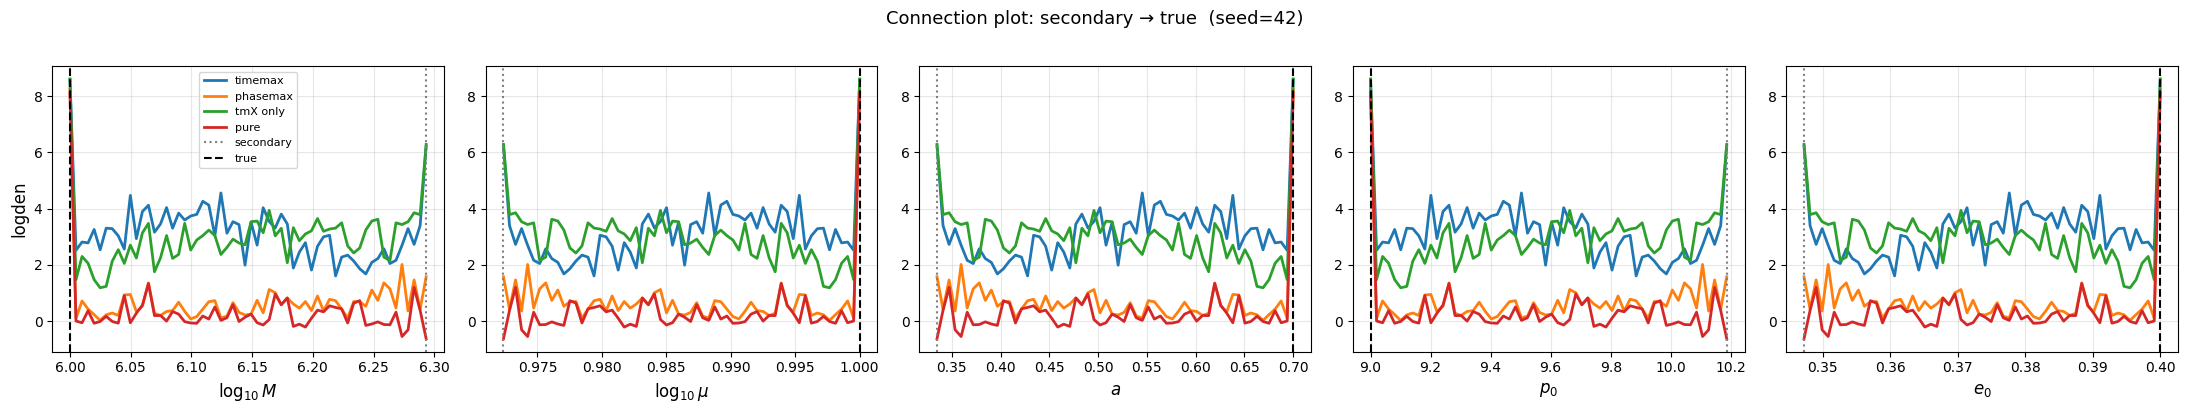

In [28]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

# ── re-use existing setup (params_star, waveform_response, gwf, xI0, dist, etc.)
# ── all 4 loglike variants share the same signal (same seed=42)

import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_tmXonly_noise
import loglike_pure_noise

ll_kwargs = dict(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)

print("Initializing timemax...")
ll_tm   = loglike_timemax_noise.LogLike(**ll_kwargs)
print("Initializing phasemax...")
ll_pm   = loglike_phasemax_noise.LogLike(**ll_kwargs)
print("Initializing tmXonly...")
ll_tmX  = loglike_tmXonly_noise.LogLike(**ll_kwargs)
print("Initializing pure...")
ll_pure = loglike_pure_noise.LogLike(**ll_kwargs)
print("All initialized.")

def make_log_density(ll_obj):
    """Wrap a LogLike object into a batched log_density function."""
    def _ld(params):
        params = np.asarray(params)
        out = np.zeros(params.shape[0])
        for i in range(params.shape[0]):
            logm1, logm2, a, p0, e0 = params[i]
            try:
                val = ll_obj(np.array([
                    10**logm1, 10**logm2, a, p0, e0,
                    xI0, dist, qS, phiS, qK, phiK,
                    Phi_phi0, Phi_theta0, Phi_r0
                ]))
            except Exception:
                val = -np.inf
            out[i] = val
        return out
    return _ld

ld_tm   = make_log_density(ll_tm)
ld_pm   = make_log_density(ll_pm)
ld_tmX  = make_log_density(ll_tmX)
ld_pure = make_log_density(ll_pure)

# ── connection line: secondary → true ─────────────────────────────────────────
secondary_pt = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])
true_pt      = np.array([6.0, 1.0, 0.7, 9.0, 0.4])

n_points = 60
t_vals = np.linspace(0, 1, n_points)
# line_pts[dim, n_points]
line_pts = secondary_pt[:, None] + t_vals * (true_pt - secondary_pt)[:, None]

print("Evaluating timemax..."); ld_line_tm   = ld_tm(line_pts.T)
print("Evaluating phasemax..."); ld_line_pm   = ld_pm(line_pts.T)
print("Evaluating tmXonly..."); ld_line_tmX  = ld_tmX(line_pts.T)
print("Evaluating pure...");    ld_line_pure = ld_pure(line_pts.T)
print("Done.")

# ── plot ───────────────────────────────────────────────────────────────────────
variants = [
    ('timemax',   ld_line_tm,   'C0'),
    ('phasemax',  ld_line_pm,   'C1'),
    ('tmX only',  ld_line_tmX,  'C2'),
    ('pure',      ld_line_pure, 'C3'),
]

param_labels = [r'$\log_{10}M$', r'$\log_{10}\mu$', r'$a$', r'$p_0$', r'$e_0$']

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for dim in range(5):
    ax = axes[dim]
    for name, ld_line, color in variants:
        ax.plot(line_pts[dim], ld_line, '-', color=color, lw=2, label=name)
    ax.axvline(secondary_pt[dim], color='gray',  ls=':', lw=1.5, label='secondary')
    ax.axvline(true_pt[dim],      color='black', ls='--', lw=1.5, label='true')
    ax.set_xlabel(param_labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)
    if dim == 0:
        ax.set_ylabel('logden', fontsize=12)

axes[0].legend(fontsize=8, loc='best')
plt.suptitle('Connection plot: secondary → true  (seed=42)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()